<a href="https://colab.research.google.com/github/Nahush11/Medical_DL/blob/main/mdl_exercise_sequence_classification_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise: ECG Classification with Transformers

The goal of this exercise is to classify (variable-length) ECG recordings of the **[PhysioNet/CinC](https://moody-challenge.physionet.org/2017/)** challenge into four rhythm classes:
+ normal sinus rhythms (N)
+ atrial fibrillation (AF)
+ other rhythms (O)
+ noise signals (∼)

We will achieve this by implementing the **[transformer](https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf)** architecture from scratch.

In [1]:
!pip install wget torchinfo
import csv
import os
import zipfile

import matplotlib.pyplot as plt
import scipy.io
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import wget
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary
from tqdm.notebook import tqdm, trange

# check if cuda and training with mixed precision is available
tensor_cores_available = False
if torch.cuda.is_available() == False:
    print("CUDA not found! It is highly recommended to enable CUDA for the exercises")
else:
    print("CUDA GPU found: ", torch.cuda.get_device_name(["0"]))
    if torch.cuda.get_device_capability("cuda")[0] >= 7:
        tensor_cores_available = True
        print(
            "Turing/Ampere with TensorCores is available, you can speed up training with FP16 precision"
        )


  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=3a1911ed263523abab321e56c59f1f046cacdbdbc4317fe28756f2ac5644edaa
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget
CUDA GPU found:  Tesla T4
Turing/Ampere with TensorCores is available, you can speed up training with FP16 precision


In [2]:
# get physionet_dataset
! wget -nc 'https://archive.physionet.org/challenge/2017/REFERENCE-v3.csv'
def get_physionet_dataset():
    # settings
    sample_rate = 300
    dataset_path = './training2017'
    dataset_url = 'https://archive.physionet.org/challenge/2017/training2017.zip'
    dataset_annotations = 'REFERENCE-v3.csv'

    # download data (this may take ~1 minute)
    if not os.path.isfile(dataset_path + '.zip'):
        wget.download(dataset_url)
    if not os.path.isdir(dataset_path):
        zipfile.ZipFile(dataset_path + '.zip','r').extractall()

    # build dataset from reference file
    with open(dataset_annotations, 'r') as f:
        reader = csv.reader(f)
        dataset = []
        label_dict = {'N': torch.tensor([0]).long(), 'A': torch.tensor([1]).long(), 'O': torch.tensor([2]).long(), '~': torch.tensor([3]).long()}
        for file_name, label in reader:
            dataset.append({'input': torch.from_numpy(scipy.io.loadmat(os.path.join(dataset_path, file_name + '.mat'))['val']).float().squeeze(),
                            'target': label_dict[label]})

    return dataset, sample_rate


--2026-05-13 07:29:13--  https://archive.physionet.org/challenge/2017/REFERENCE-v3.csv
Resolving archive.physionet.org (archive.physionet.org)... 128.30.30.88
Connecting to archive.physionet.org (archive.physionet.org)|128.30.30.88|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 76752 (75K) [text/plain]
Saving to: ‘REFERENCE-v3.csv’

REFERENCE-v3.csv    100%[===================>]  74.95K  --.-KB/s    in 0.1s    

2026-05-13 07:29:13 (515 KB/s) - ‘REFERENCE-v3.csv’ saved [76752/76752]



## Task 0: PhysioNet/CinC Challenge Data

We have provided some code for data inspection, in the following cell the Physionet dataset is loaded, relevant information is printed, and exemplary ECG rhythms are plotted.

First, we get the raw data and their corresponding labels as a list of dicts (keys: input, target). We extract the ground truth/labels and save them in the tensor `labels`. To keep the labels in a human-readable form, we also create a mapping `label_map`.

In [3]:
records_and_labels, sample_rate = get_physionet_dataset()
labels = torch.tensor([e["target"] for e in records_and_labels])
label_map = ["N", "AF", "O", "~"]


Next, we want to extract some basic information from our dataset like the number of recordings its holding as well as the class distribution.

number of recordings:  8528
number of classes: 4


(0.0, 1.0)

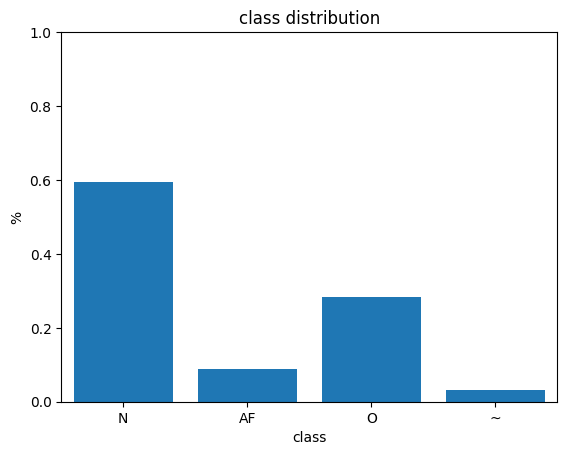

In [4]:
# number of recordings
num_recordings = len(labels)
print("number of recordings: ", num_recordings)

# number of classes
num_classes = torch.unique(labels).numel()
print("number of classes:", num_classes)

# class distribution
class_distribution = torch.histc(labels.float(), bins=num_classes) / num_recordings
plt.figure("class distribution")
plt.bar(torch.arange(num_classes), class_distribution)
plt.title("class distribution")
plt.xlabel("class")
plt.xticks(ticks=torch.arange(num_classes), labels=label_map)
plt.xlim([-0.5, num_classes - 0.5])
plt.ylabel("%")
plt.ylim([0, 1])


Let's plot an example for our four ECG types.

Text(0.5, 0, 'sec')

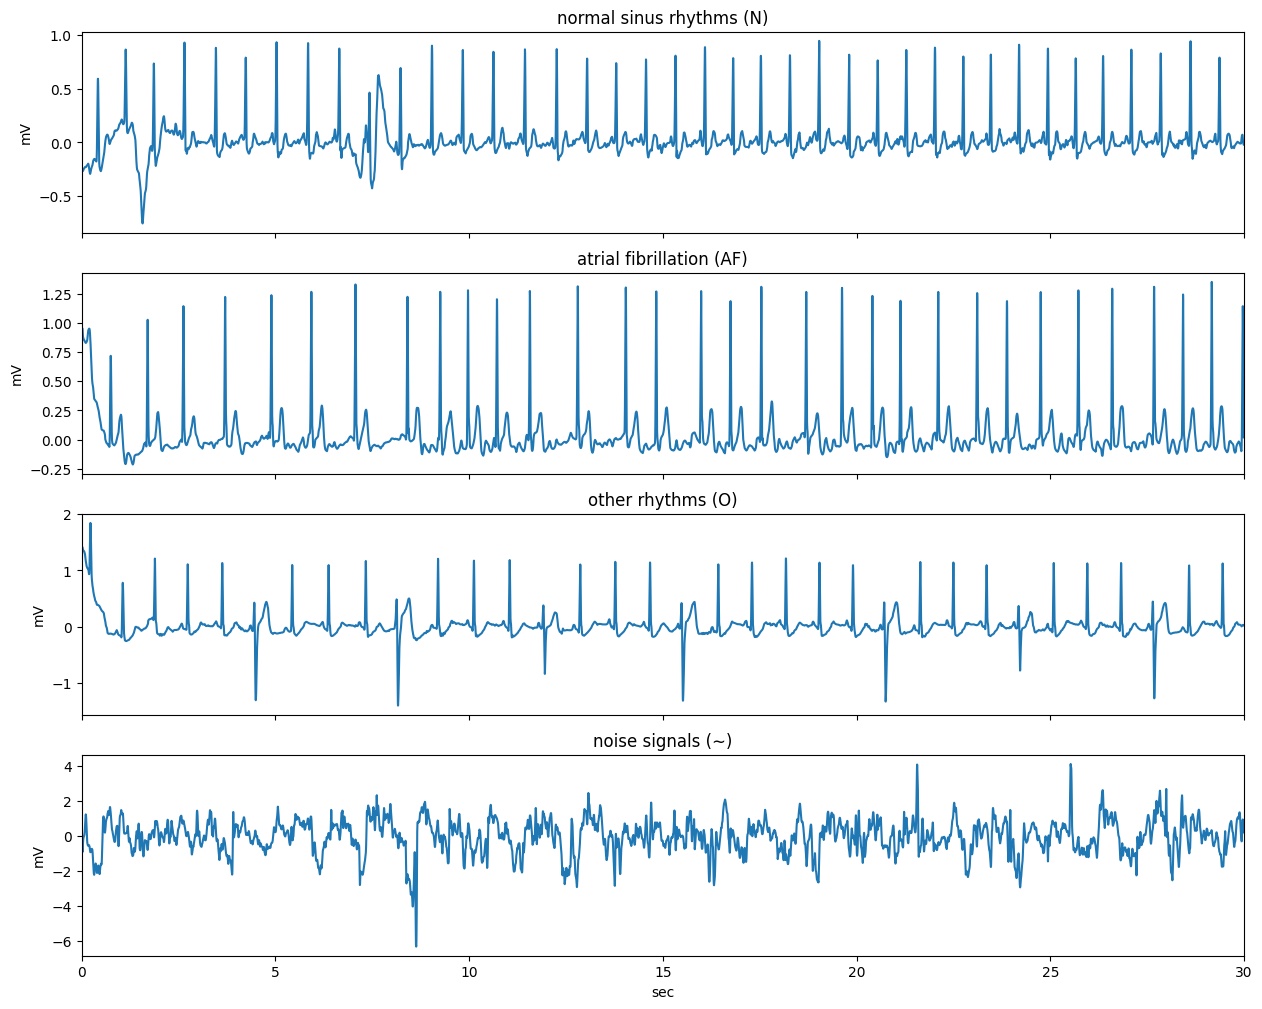

In [5]:
# plot signals (one example for each target)
fig, axs = plt.subplots(num_classes, 1, sharex=True, figsize=(15, 3 * num_classes))
index = [0, 3, 76, 1245]
long_label_mapping = [
    "normal sinus rhythms (N)",
    "atrial fibrillation (AF)",
    "other rhythms (O)",
    "noise signals (∼)",
]

for i in range(num_classes):
    signal = records_and_labels[index[i]]["input"]
    axs[i].plot(
        (torch.arange(signal.numel()).float() / sample_rate).numpy(),
        (signal / 1000).numpy(),
    )
    axs[i].set_title(long_label_mapping[i])
    axs[i].set_xlim([0, 30])
    axs[i].set_ylabel("mV")
axs[i].set_xlabel("sec")


Finally, we want to extract some information about the signal length distribution.

Text(0.5, 9.444444444444438, 'sec')

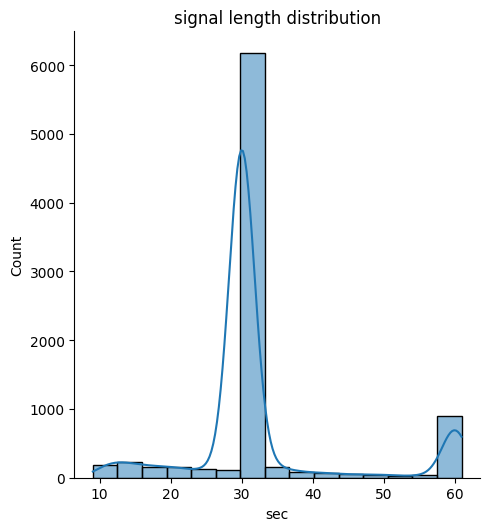

In [6]:
import seaborn as sns

sns.displot(
    [entry["input"].numel() / sample_rate for entry in records_and_labels], kde=True
)
plt.title("signal length distribution")
plt.xlabel("sec")


## Task 1: Preprocessing

As you saw in the previous cell, the recordings in the dataset are not normalized and of variable sequence length.

To use the ECG signals with our neural nets we need to normalize each recording $s$ to have *zero mean* and *unit variance*.
$$
s'=\frac{s-\mu_s}{\sigma_s}
$$
where $\mu_s$ and $\sigma_s$ are the mean and standard deviation calculated over each record in the dataset. Iterate over the dataset to calculate $\mu$ and $\sigma$ for each record and normalize it.

In [13]:
# normalize each recording
for i in range(num_recordings):
    # load
    signal = records_and_labels[i]['input']
    mean_of_signal = signal.mean()

    std_of_signal = signal.std()


    signal = (signal - mean_of_signal)/std_of_signal
    print(signal)

    # save
    records_and_labels[i]['input'] = signal


Streaming output truncated to the last 5000 lines.
tensor([0.7846, 0.9175, 1.0424,  ..., 0.1362, 0.1322, 0.1282])
tensor([2.0574, 2.4623, 2.8534,  ..., 0.0881, 0.3823, 0.3857])
tensor([-0.4565, -0.5450, -0.6093,  ..., -0.1389, -0.1148, -0.0947])
tensor([0.2215, 0.2570, 0.2864,  ..., 0.7321, 0.5240, 0.3231])
tensor([ 2.4041,  3.1519,  3.9471,  ...,  0.0080, -0.0044, -0.0209])
tensor([-0.1752, -0.1752, -0.1752,  ..., -0.3298, -0.2353, -0.1580])
tensor([-2.0940, -2.4565, -2.8485,  ..., -0.2597, -0.2301, -0.1931])
tensor([ 0.0204,  0.0426,  0.0648,  ..., -0.3126, -0.2534, -0.2016])
tensor([1.0514, 1.4286, 1.7682,  ..., 0.3347, 0.2718, 0.1460])
tensor([ 0.7638,  0.8557,  0.8925,  ..., -0.0547, -0.0455, -0.0363])
tensor([ 0.1183,  0.1399,  0.2697,  ..., -0.2601, -0.2169, -0.1628])
tensor([5.0170, 5.9310, 6.9386,  ..., 0.0521, 0.0209, 0.0105])
tensor([0.5421, 0.7189, 0.9062,  ..., 1.3985, 1.1281, 0.8819])
tensor([0.1552, 0.1552, 0.1580,  ..., 0.9413, 0.6483, 0.3579])
tensor([ 3.2569,  3.8577,

To make the handling of the data easier, we want to ensure, that all signals have the **same length of 30 seconds**. To do that, iterate over the data:
* if a recording is longer than 30 seconds crop it symmetrically
* if it is shorter pad the signal with zeros using `F.pad` ([pytorch-doc](https://pytorch.org/docs/stable/generated/torch.nn.functional.pad.html)), again symmetrically.

To obtain the length of the signal in seconds, divide its length/number of elements with the `sample_rate` in Hz (it is the same for all recordings). The cropped or padded signal should then append to the list `data`.

In [ ]:
# to fixed signal length
fixed_signal_length = 30
for i in range(num_recordings):
    # load
    signal = records_and_labels[i]["input"]

    signal_length = signal.numel() / sample_rate
    # TODO

    # save
    records_and_labels[i]["input"] = signal


As you can remember from the class distribution plot, the classes $\omega$ are unbalanced. So we create class weights $w_\omega$ to weight the loss during training. We obtain them with the formula of the **root inverse frequency**:
$$ w_{\omega_i} = \sqrt{(P_{\omega_i})^{-1}}$$
We calculate $P_{\omega_i}$ by counting the labels with `torch.bincount` and dividing them by `num_recordings`. The first element of the weight tensor should contain $1.2962$.

In [ ]:
#TODO
class_weights = #TODO
class_weights


Next, we prepare all data in datasets for training and validation. In this exercise we perform a single fold validation on a fixed train/valid set (with ratio 90:10).

In [ ]:
# provided dataset class
class CinCDataset(Dataset):
    def __init__(self, data: torch.Tensor, ground_truth: torch.Tensor):
        super().__init__()
        self.data = data.unsqueeze(1)
        self.ground_truth = ground_truth

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.ground_truth[idx]


# for reproducibility (do not change)
torch.manual_seed(0)

# split dataset in train/valid set
ratio = 0.9
split = int(num_recordings * ratio)
perm = torch.randperm(num_recordings)

dataset_train = [records_and_labels[i] for i in perm[:split]]
dataset_valid = [records_and_labels[i] for i in perm[split:]]

input_train = torch.stack([entry["input"] for entry in dataset_train])
target_train = torch.cat([entry["target"] for entry in dataset_train])
input_valid = torch.stack([entry["input"] for entry in dataset_valid])
target_valid = torch.cat([entry["target"] for entry in dataset_valid])

# create dataloader for training
train_dataset = CinCDataset(input_train, target_train)
val_dataset = CinCDataset(input_valid, target_valid)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True, num_workers=4)
val_dataloader = DataLoader(val_dataset, batch_size=32, drop_last=False, num_workers=4)

## Task 2: Implementing the transformer
### Task 2.1: Self-attention
Let's start with the heart of the transformer: the **self-attention mechanism**. As an example, let's assume that the tensor $x\in\mathbb{N}^{B\times L \times C}$ holds a batch $B$ of sequences of $L$ vectors each of dimension $C$. With this, we can express the self-attention mechanism using matrix multiplication as follows:
$$
\begin{aligned}
w' = x \cdot x^T\\
w = \text{softmax}(w')\\
y = w \cdot x\\
\end{aligned}
$$
where $w$ is the attention matrix and $y$ the output holding the attended sequences. Implement self-attention using the provided $x$ and formulas above. The softmax should be applied row-wise.

In [ ]:
x = torch.tensor([[[5, 2, 6, 2],
                   [5, 0, 2, 7],
                   [7, 6, 7, 8]],

                  [[2, 8, 7, 2],
                   [7, 6, 4, 2],
                   [5, 5, 8, 7]]], dtype=torch.float)
w_prime = #TODO
w = #TODO
y = #TODO

assert torch.allclose(y, torch.tensor([[[7.0000, 6.0000, 7.0000, 8.0000],
                                     [7.0000, 6.0000, 7.0000, 8.0000],
                                     [7.0000, 6.0000, 7.0000, 8.0000]],
                                    [[2.8068, 7.1932, 7.2689, 3.3447],
                                     [5.0049, 5.0025, 7.9901, 6.9876],
                                     [5.0000, 5.0000, 8.0000, 7.0000]]])), f'hmm something seems to be wrong here...\n {y} does not match the expected output.'


![self-attention](https://cloud.imi.uni-luebeck.de/s/ftGmoMYERiKw4qF/download)

As you can notice, the basic self-attention does not include any learnable parameters, so our model would not be able to extract some semantics of the data. To overcome this, we introduce three linear and learnable transformations (`nn.Linear` without bias) given each vector $x_i$ in the sequence three different roles:
* the **query** $q_i=W_qx_i$ and
* the **key** $k_j=W_kx_j$ vectors represent a learnable correlation of how important or similar the $i$-th vector is for the $j$-th vector.
* the **value** $v_j=W_vx_j$ vector represents the learned semantic that is then weighted by the correlation score and forwarded to the output.

This gives the self-attention layer some controllable parameters, and allows it to modify the incoming vectors to suit the three roles they must play.

Now, follow the same procedure as above, but this time use the learnable transformations $W_q$, $W_k$, and $W_v$ to calculate the query, key, and value vectors. Remember, that we implement everything in parallel for the whole batch.
$$
\begin{aligned}
w' &= q \cdot k^T\\
w' &= \frac{w'}{\sqrt{C}}\\
w &= \text{softmax}(w')\\
y &= w \cdot v
\end{aligned}
$$
The scaling of the raw weights $w'$ is necessary due to the sensitivity of the `softmax` to large values. Dividing by the dimensionality of the vectors $C$ normalizes it to a more stable range.

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, C: int):
        super().__init__()

        # These compute the queries, keys and values
        self.tokeys    = #TODO
        self.toqueries = #TODO
        self.tovalues  = #TODO

    def forward(self, x):
        B, L, C = x.size()

        # transform x to queries, keys and values (B, L, C) -> (B, L, C)
        queries = #TODO
        keys    = #TODO
        values  = #TODO

        # Get dot product of queries and keys containing raw weights
        raw_weights = t#TODO

        # scale the dot product
        weights = #TODO

        # normalize
        weights = #TODO

        # apply the self attention to the values
        values = #TODO

        return values


### Task 2.2: Transformer Block
![transformer-block](https://cloud.imi.uni-luebeck.de/s/r74Gs86587esWjx/download)

Since the transformer architecture also includes an element-wise non-linear transformation to further abstract features, we need to implement a **feedforward layer** and put it all together in a **transformer block**. This block consists of:
* our implemented **self-attention layer**
* a **normalization layer** (we use `nn.LayerNorm`) over `embed_dim` ($C$) dimension
* a **feedforward layer** applied independently to each vector in the sequence and consists of two linear layers with a ReLU activation in between. The first linear layer should increase the dimensionality of the vectors to `ff_dim` and the second one decrease it back to the original dimensionality `embed_dim`. We set the `ff_dim` to 512.
* a second **normalization layer**

To stabilize the training of the model, we add a **skip connection** around the self-attention and feedforward layer. This is implemented by adding the input to the output of the self-attention layer and the feedforward layer respectively before applying normalization.

In [ ]:
class TransformerBlock(nn.Module):
  def __init__(self, embed_dim:int, ff_dim:int):
    super().__init__()

    self.attention = #TODO

    self.norm1 = #TODO
    self.norm2 = #TODO

    self.ff = #TODO

  def forward(self, x):
    #TODO
    return #TODO



### Task 2.3: Patch Embedding
The self-attention mechanism itself is permutation invariant, meaning that the order of the input vectors does not matter. However, since our ECG signal is causal, we need to introduce a way to preserve the order of the input vectors. This could be achieved by either adding some periodic positional information to the input vectors (e.g. using sinus and cosinus) or we can introduce a learnable patch embedding. For this exercise, we will go with the second options and implement the patch embedding via `nn.Conv1d` layer, where the patch size defines the kernel size. Note, that it is crucial for the patch embedding to extract overlapping patches from the input signal. This is done by setting the `stride` parameter of the `nn.Conv1d`. Use the `padding` parameter to ensure that the output has the same length as the input and introduce normalization via an `nn.LayerNorm` layer. Make sure to normalize over the same dimension as in the self-attention layer! For the activation function, we use ReLU.

Since the `nn.Conv1d` layer expects the input in the format $B \times C \times L$ but our self-attention layer expect it to be $B \times L \times C$, we need to transpose the input tensor before and after the convolution.

In [ ]:
class OverlapPatchEmbed(nn.Module):
    def __init__(self, in_channel: int, embed_dim: int, patch_size=7, stride=4):
        super().__init__()

        self.embed = #TODO
        self.norm = #TODO
        self.activation = #TODO

    def forward(self, x):
        #TODO

        return x


### Task 2.4: Transformer Classifier

Now, let's put it all together and implement a simple transformer classifier. Its transformer encoder consists of four groups, each starting with an `OverlapPatchEmbed` layer followed by a number of `TransformerBlock` layers.
1. Group has one `TransformerBlock` layer
2. Group has one `TransformerBlock` layer
3. Group has two `TransformerBlock` layers
4. Group has three `TransformerBlock` layers

The actual classification is achieved by a linear layer (with bias) that takes the mean over the sequence dimension and maps it to the number of classes.


In [ ]:
class MyHierarchicalTransformer(nn.Module):
    def __init__(self, embed_dim:int=64, ff_dim:int=512):
        super().__init__()

        self.encoder = #TODO

        self.classifier = nn.Linear(embed_dim, 4)


    def forward(self, x):
        x = x.transpose(-1, -2) # (B, C, L)  ->  (B, L, C)
        #TODO

        return x


Check your implementation by running the `summary` function on your `MyHierarchicalTransformer`. Your architecture should have around $638\,084$ parameters.

In [ ]:
summary(MyHierarchicalTransformer(), (1, 1, 30 * sample_rate))


## Task 3: Training routine
Complete the training routine function `train` below. For the training use:
- Adam optimizer with an initial learning rate of __0.0001__ (differs from Adam's default!).
- cross-entropy loss with root-inverse class weighting to encounter for the class-imbalance.
- let the model train for __15__ epochs.

Useful PyTorch functions: `optim.Adam(), nn.CrossEntropyLoss()`

In [ ]:
from torch.cuda import amp
import torchmetrics as metric


def train(model, num_epochs=15, lr=0.0001):
    # optimizer
    optimizer = #TODO
    scaler = amp.GradScaler()

    # criterion
    criterion = #TODO

    # for reproducibility (do not change)
    torch.manual_seed(0)

    # statistics
    ce_mean = metric.MeanMetric().cuda()
    f1_metric = metric.classification.MulticlassF1Score(num_classes).cuda()
    best_val_f1 = []
    acc_metric = metric.classification.MulticlassAccuracy(num_classes).cuda()
    best_val_acc = []

    # for num_epochs
    for epoch in trange(num_epochs, unit='epoch'):

        # train mode
        model.train()

        # statistics
        ce_mean.reset()
        f1_metric.reset()

        # for each mini-batch
        for input, target in train_dataloader:
            input = input.cuda(non_blocking=True)
            target = target.cuda(non_blocking=True)

            # zero the parameter gradients
            #TODO

            # forward + backward + optimize
            with amp.autocast(enabled=tensor_cores_available):
                output = #TODO
                loss = #TODO
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            # statistics
            ce_mean(loss)
            f1_metric(output, target)
            acc_metric(output, target)

        # output
        tqdm.write('Epoch {} (train) -- loss: {:.4f} acc: {:.4f} f1: {:.4f}'.format(epoch, ce_mean.compute(),
                                                                                    acc_metric.compute(),
                                                                                    f1_metric.compute()))

        # validate

        # eval mode
        model.eval()

        # statistics
        ce_mean.reset()
        f1_metric.reset()
        acc_metric.reset()

        # for each mini-batch
        for input, target in val_dataloader:
            input = input.cuda(non_blocking=True)
            target = target.cuda(non_blocking=True)

            # forward
            with torch.no_grad(), amp.autocast(enabled=tensor_cores_available):
                output = #TODO
                loss = #TODO

            # statistics
            ce_mean(loss)
            f1_metric(output, target)
            acc_metric(output, target)

        # output
        tqdm.write('Epoch {} (valid) -- loss: {:.4f} acc: {:.4f} f1: {:.4f}\n'.format(epoch, ce_mean.compute(),
                                                                                      acc_metric.compute(),
                                                                                      f1_metric.compute()))
        # statistics
        best_val_f1.append(f1_metric.compute().item())
        best_val_acc.append(acc_metric.compute().item())
        ce_mean.reset()
        f1_metric.reset()
        acc_metric.reset()

    # make model callable outside this function
    train.trained_model = model

    # best validation score
    print('Best accuracy (valid):', '{:.2f}'.format(round(max(best_val_acc), 2)))
    print('Best F1 score (valid):', '{:.2f}'.format(round(max(best_val_f1), 2)))


Call the training function to train your `MyHierarchicalTransformer` for __15__ epochs.
After training the best validation F1 score should be around 0.64 (Accuracy around 0.68).

In [ ]:
# TODO


# Bonus Task: Multi-headed self-attention (10 points)

![multi-head](https://cloud.imi.uni-luebeck.de/s/5scNiLwcqC3REbo/download)

In the transformer architecture, the self-attention mechanism can be extended to multiple heads. This allows the model to learn different attention patterns in parallel. In the exercise above, we used a single head for the self-attention mechanism. Now, we want to extend it to multiple heads.
For this, you can think of it in that way, that we introduce multiple sets of $W_q$, $W_k$, and $W_v$ for each head. However, this would increase the amount of parameters and the computational complexity. To keep the number of parameters constant, we implement the multi-head self-attention mechanism by splitting all $W$ matrices into $h$ heads and concatenate the results at the end.
So the linear transformations to queries, keys, and values stay the same, and we only have to slice their dimensionality into $h$ heads. You can achieve this by viewing the tensors appropriately. Since the self-attention should be calculated for each head independently, we have to reshape all tensors accordingly, so that the batch and head dimensions are combined for the batched matrix multiplication. After the scaling and softmax-normalisation, and calculation of the output values, we have to reshape them back into their original shape.
As a last step, we unify the heads by applying a linear transformation $W_o$ to the concatenated heads (implemented via a additional `nn.Linear` over $C$).

In [ ]:
class SelfAttentionMultiHead(nn.Module):
    def __init__(self, C, heads=4):
        super().__init__()

        assert C % heads == 0

        self.C, self.heads = C, heads

        # These compute the queries, keys and values for all
        # heads
        self.tokeys    = #TODO
        self.toqueries = #TODO
        self.tovalues  = #TODO

        # This will be applied after the multi-head self-attention operation.
        self.unifyheads = #TODO

    def forward(self, x):
        b, t, k = x.size()
        h = self.heads

        #TODO

        return #TODO


Replace the `SelfAttention` layer in the `TransformerBlock` with the `SelfAttentionMultiHead` layer and train the model again. The best validation F1 score should be around 0.66 (Accuracy around 0.70).

In [ ]:
# TODO
